In [17]:
# Concatination

import pandas as pd

df1 = pd.DataFrame({
    "acc": [1,2,3],
    "name": ["Ram","Shyam","Hari"],
    "age": [2,3,4]
    })

In [18]:
df1

,acc,name,age
0,1,Ram,2
1,2,Shyam,3
2,3,Hari,4


In [19]:
df2 = pd.DataFrame({
    "acc": [5,6,7],
    "loan": [44,55,66]
})

In [20]:
df2

,acc,loan
0,5,44
1,6,55
2,7,66


In [21]:
row_concat = pd.concat([df1,df2], axis=0)

In [22]:
row_concat


,acc,name,age,loan
0,1,Ram,2.0,NaN
1,2,Shyam,3.0,NaN
2,3,Hari,4.0,NaN
0,5,NaN,NaN,44.0
1,6,NaN,NaN,55.0
2,7,NaN,NaN,66.0


In [23]:
column_concat = pd.concat([df1,df2], axis=1)

In [24]:
column_concat

,acc,name,age,acc,loan
0,1,Ram,2,5,44
1,2,Shyam,3,6,55
2,3,Hari,4,7,66


In [25]:
# Merge

# Merging is the process of combining two or more dataframes based on common columns.

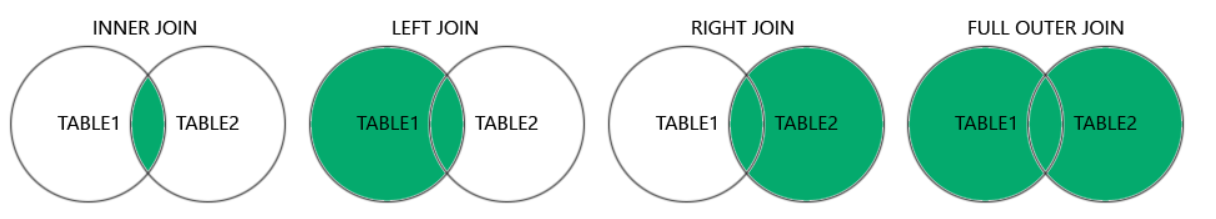

In [26]:
students = pd.DataFrame({
    "ID": [1,2,3],
    "Name": ["Ram", "Shyam", "Hari"]

})

In [27]:
marks = pd.DataFrame({
    "ID": [1,5,6],
    "Marks": [85,90,78]
})

In [28]:
pd.merge(students, marks, how="right", on="ID")

,ID,Name,Marks
0,1,Ram,85
1,5,NaN,90
2,6,NaN,78


# Join in pandas
Joining is similar to merging, but is specifically used to combine dataframes based on their indexes. You can use the pd.DataFrame.join() method to join dataframes.

In [29]:
df1 = pd.DataFrame(
    {
        "key": ["E", "B", "C", "Z"],
        "inv_val": [99, 55,33,22],
        "acc": [1,2,5,7]
    }
)
df1

,key,inv_val,acc
0,E,99,1
1,B,55,2
2,C,33,5
3,Z,22,7


In [30]:
df1 = df1.set_index("key")

In [31]:
df1

,inv_val,acc
key,,
E,99,1
B,55,2
C,33,5
Z,22,7


In [32]:
df2 = pd.DataFrame(
    {
        "key": ["A","B","C","D"],
        "hel_ration": [66,0.67,67,20],
        "acc": [11,32,53,74]
    }
)

In [33]:
df2

,key,hel_ration,acc
0,A,66.00,11
1,B,0.67,32
2,C,67.00,53
3,D,20.00,74


In [34]:
df2 = df2.set_index("key")

In [35]:
df2

,hel_ration,acc
key,,
A,66.00,11
B,0.67,32
C,67.00,53
D,20.00,74


In [36]:
df1.join(df2, how="outer", lsuffix="_x")

,inv_val,acc_x,hel_ration,acc
key,,,,
A,NaN,NaN,66.00,11.0
B,55.0,2.0,0.67,32.0
C,33.0,5.0,67.00,53.0
D,NaN,NaN,20.00,74.0
E,99.0,1.0,NaN,NaN
Z,22.0,7.0,NaN,NaN


In [37]:
df2.join(df1, how ="inner", rsuffix="_2")

,hel_ration,acc,inv_val,acc_2
key,,,,
B,0.67,32,55,2
C,67.00,53,33,5


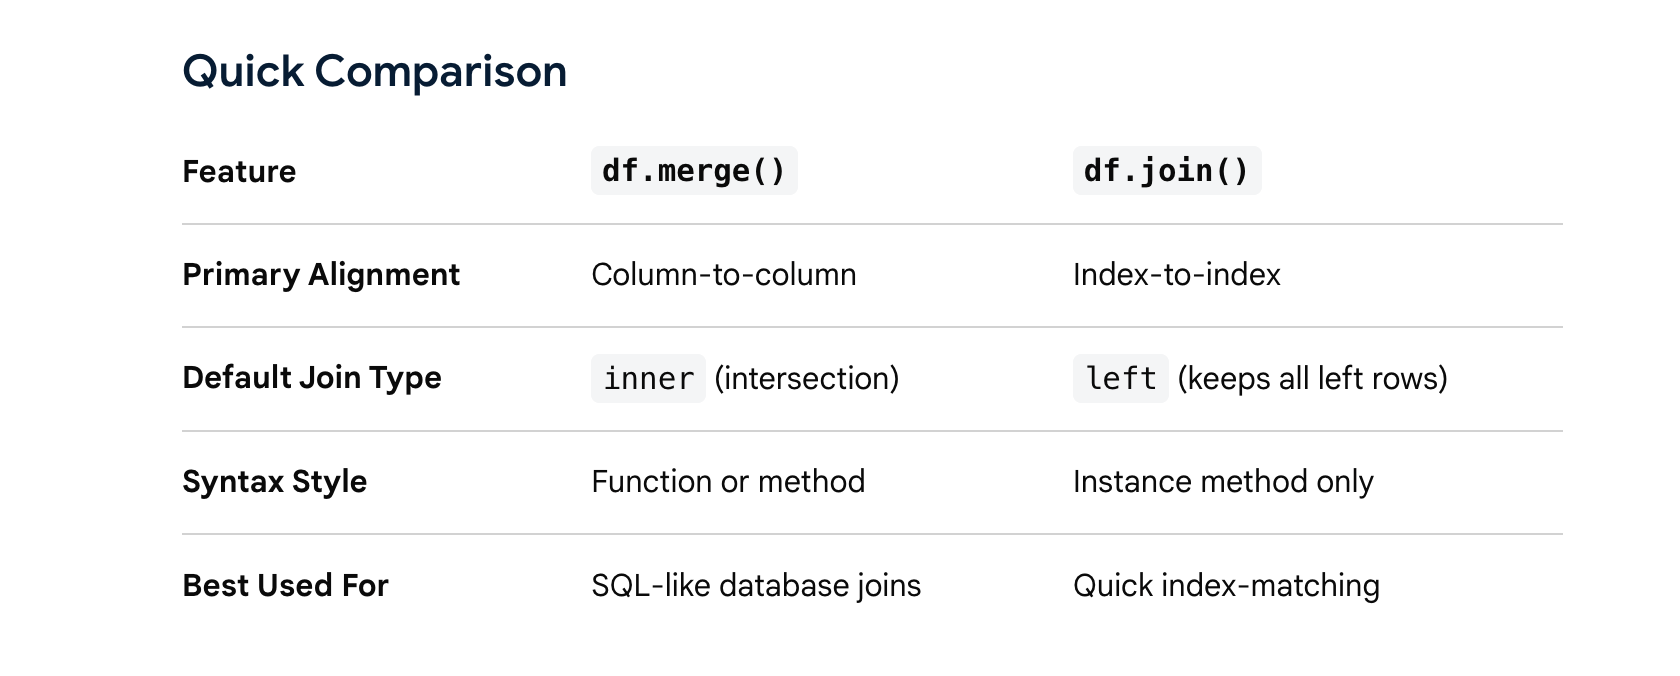

#Stacking

Stacking is the process of vertically combining datasets with the same columns. The datasets are aligned by their column names and then stacked on top of each other. You can use the dataframe.stack() function to stack a dataframe.

In [38]:
df2 = pd.DataFrame(
    {
        "key": ["A","B","C","D"],
        "hel_ration": [66,0.67,67,20],
        "acc": [11,32,53,74]
    },index=["W","X","Y","Z"]
)
df2

,key,hel_ration,acc
W,A,66.00,11
X,B,0.67,32
Y,C,67.00,53
Z,D,20.00,74


In [39]:
# stack = move columns into rows

# It is mainly used for reshaping data, rather than combining independent datasets.

stacked = df2.stack()
stacked

W  key              A
   hel_ration    66.0
   acc             11
X  key              B
   hel_ration    0.67
   acc             32
Y  key              C
   hel_ration    67.0
   acc             53
Z  key              D
   hel_ration    20.0
   acc             74
dtype: object

In [40]:
# concat, merge, join, stack => Data integration

Real-world example

Imagine an e-commerce company:

January sales + February sales → concat()

Customers + Orders using Customer_ID → merge()

Sales data + customer information using index → join()

Monthly columns → individual month rows → stack()

One important correction: calling all four "data integration" is slightly misleading. concat, merge, and join are primarily data-combination/integration operations; stack() is primarily a data reshaping operation.

In [41]:
# Encoding

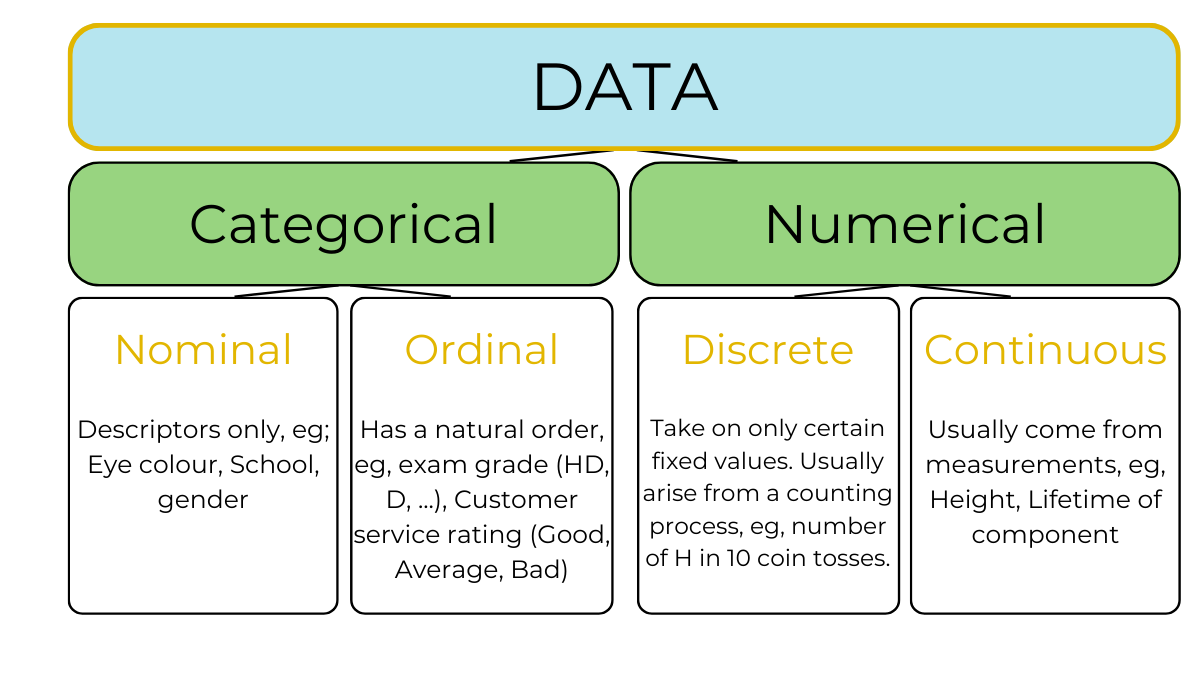

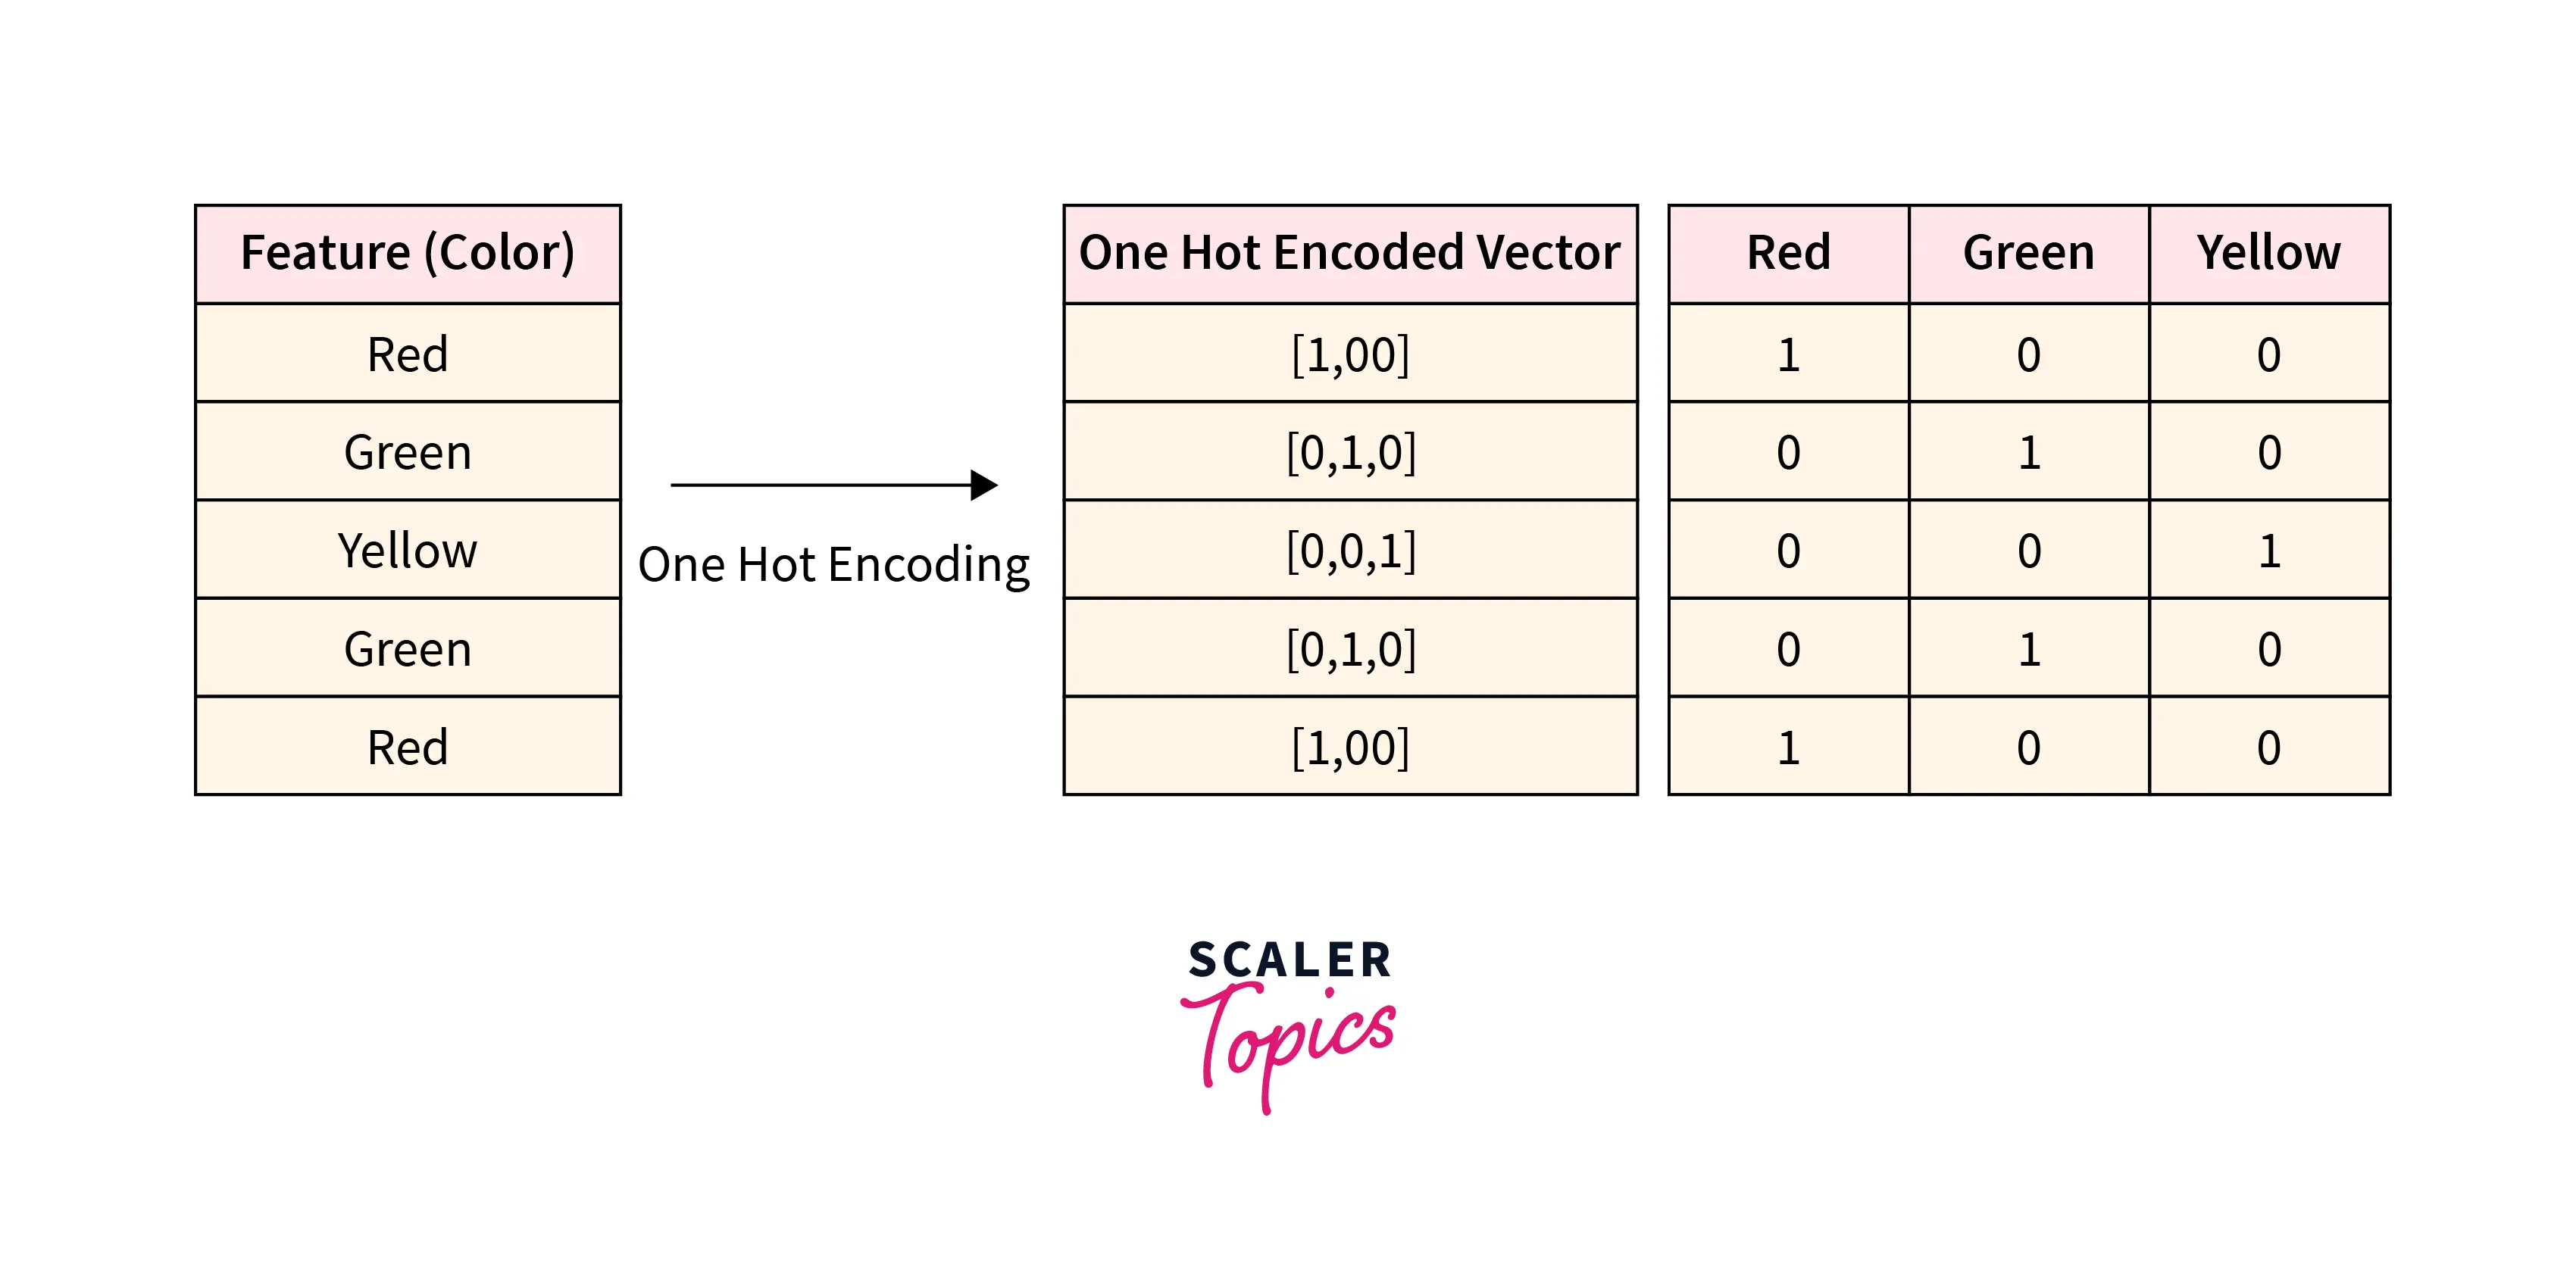

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [43]:
titanic_df = pd.read_csv("/content/drive/MyDrive/dsml12/titanic-data.csv")

In [44]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [45]:
titanic_df["Sex"]

,Sex
0,male
1,female
2,female
3,female
4,male
...,...
886,male
887,female
888,female
889,male


In [46]:
pd.get_dummies(titanic_df, columns=["Sex"], dtype=int)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_female,Sex_male
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,1,0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,S,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,S,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,1,2,W./C. 6607,23.4500,NaN,S,1,0
889,890,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,C,0,1


In [47]:
pd.get_dummies(titanic_df, columns=["Embarked"], dtype=int)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,0,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,0,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,1,0,0
